In [ ]:
# Core libraries
import os
import gzip
import random

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/CSCI4481 Project/Bacteria"
DATA_RAW = f"{BASE_PATH}/data_raw"
DATA_PROCESSED = f"{BASE_PATH}/data_processed"

!mkdir -p "$DATA_RAW"
!mkdir -p "$DATA_PROCESSED"

BASE_PATH, DATA_RAW, DATA_PROCESSED



Mounted at /content/drive


('/content/drive/MyDrive/CSCI4481 Project/Bacteria',
 '/content/drive/MyDrive/CSCI4481 Project/Bacteria/data_raw',
 '/content/drive/MyDrive/CSCI4481 Project/Bacteria/data_processed')

In [ ]:
# E. coli K-12 MG1655
base_url = "https://ftp.ncbi.nlm.nih.gov/genomes/refseq/bacteria/Escherichia_coli/reference/GCF_000005845.2_ASM584v2"

genomic_fna_url = f"{base_url}/GCF_000005845.2_ASM584v2_genomic.fna.gz"
genomic_gff_url = f"{base_url}/GCF_000005845.2_ASM584v2_genomic.gff.gz"

genomic_fna_path = f"{DATA_RAW}/genomic.fna.gz"
genomic_gff_path = f"{DATA_RAW}/genomic.gff.gz"

!wget -O "$genomic_fna_path" "$genomic_fna_url"
!wget -O "$genomic_gff_path" "$genomic_gff_url"

!ls -lh "$DATA_RAW"


--2025-12-09 00:55:17--  https://ftp.ncbi.nlm.nih.gov/genomes/refseq/bacteria/Escherichia_coli/reference/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.12, 130.14.250.13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1379902 (1.3M) [application/x-gzip]
Saving to: ‘/content/drive/MyDrive/CSCI4481 Project/Bacteria/data_raw/genomic.fna.gz’

/content/drive/MyDr 100%[===================>]   1.32M  1019KB/s    in 1.3s    

2025-12-09 00:55:20 (1019 KB/s) - ‘/content/drive/MyDrive/CSCI4481 Project/Bacteria/data_raw/genomic.fna.gz’ saved [1379902/1379902]

--2025-12-09 00:55:21--  https://ftp.ncbi.nlm.nih.gov/genomes/refseq/bacteria/Escherichia_coli/reference/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.7,

In [ ]:
import gzip

def load_genome_fasta(fasta_gz_path):
    seq_parts = []
    with gzip.open(fasta_gz_path, "rt") as f:
        for line in f:
            if not line.startswith(">"):
                seq_parts.append(line.strip().upper())
    return "".join(seq_parts)

genome_seq = load_genome_fasta(genomic_fna_path)
len(genome_seq)


4641652

In [ ]:
def parse_gff_cds_starts(gff_gz_path):
    starts = []
    with gzip.open(gff_gz_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue

            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue

            chrom, source, ftype, start, end, score, strand, phase, attrs = parts

            if ftype != "CDS":
                continue

            start = int(start)
            end = int(end)

            if strand == "+":
                starts.append(start)
            else:  # minus strand
                starts.append(end)

    return sorted(starts)

cds_starts = parse_gff_cds_starts(genomic_gff_path)

len(cds_starts), cds_starts[:10]


(4340, [190, 337, 2801, 3734, 5234, 6459, 7959, 8238, 9306, 10494])

In [ ]:
cds_start_path = f"{DATA_PROCESSED}/cds_start_positions.txt"

with open(cds_start_path, "w") as f:
    for s in cds_starts:
        f.write(str(s) + "\n")

cds_start_path


'/content/drive/MyDrive/CSCI4481 Project/Bacteria/data_processed/cds_start_positions.txt'

In [ ]:
WINDOW = 401
HALF = WINDOW // 2

def extract_positive_windows(genome, starts, window=WINDOW):
    positives = []
    half = window // 2
    N = len(genome)

    for s in starts:
        s0 = s - 1
        left = s0 - half
        right = s0 + half + 1

        if left < 0 or right > N:
            continue

        positives.append(genome[left:right])
    return positives

positive_windows = extract_positive_windows(genome_seq, cds_starts)

len(positive_windows), positive_windows[0][:50]


(4339, 'CCAATATAGGCATAGCGCACAGACAGATAAAAATTACAGAGTACACAACA')

In [ ]:
import random

def generate_negatives_iteration2(genome, starts, window=401):
    """
    Iteration 2: Reliable negative sampling for bacteria.
    Steps:
      1. Scan genome for ALL start-like codons (ATG, GTG, TTG)
      2. Remove real start sites
      3. Remove positions near boundaries
      4. Randomly select negatives to match positive count
    """

    half = window // 2
    N = len(genome)
    true_starts = set(starts)

    start_codons = ["ATG", "GTG", "TTG"]

    candidate_positions = []

    # --- Step 1: Scan genome for all start-like codons ---
    for i in range(N - 3):
        codon = genome[i:i+3]
        if codon in start_codons:
            pos_1based = i + 1
            candidate_positions.append(pos_1based)

    # --- Step 2: Remove real CDS starts ---
    candidate_positions = [p for p in candidate_positions if p not in true_starts]

    # --- Step 3: Remove positions too close to boundaries ---
    candidate_positions = [
        p for p in candidate_positions
        if (p - 1 - half >= 0) and (p - 1 + half < N)
    ]

    print("Total candidate negatives available:", len(candidate_positions))

    # --- Step 4: Sample negatives equal to number of positives ---
    needed = len(starts)

    if len(candidate_positions) < needed:
        raise ValueError("Not enough candidate negatives found. Reduce window or relax constraints.")

    chosen = random.sample(candidate_positions, needed)

    # Extract windows
    negatives = []
    for p in chosen:
        s0 = p - 1
        left = s0 - half
        right = s0 + half + 1
        negatives.append(genome[left:right])

    return negatives
negative_windows = generate_negatives_iteration2(genome_seq, cds_starts, WINDOW)
print("Negative windows:", len(negative_windows))




Total candidate negatives available: 217154
Negative windows: 4340


In [ ]:
import pandas as pd

pos_df = pd.DataFrame({"sequence": positive_windows, "label": 1})
neg_df = pd.DataFrame({"sequence": negative_windows, "label": 0})

df = pd.concat([pos_df, neg_df], ignore_index=True)
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Dataset size:", df.shape)
print(df.label.value_counts())

csv_path = f"{DATA_PROCESSED}/training_dataset.csv"
df.to_csv(csv_path, index=False)

csv_path


Dataset size: (8679, 2)
label
0    4340
1    4339
Name: count, dtype: int64


'/content/drive/MyDrive/CSCI4481 Project/Bacteria/data_processed/training_dataset.csv'

In [ ]:
BASE_TO_VEC = {
    "A": [1,0,0,0],
    "C": [0,1,0,0],
    "G": [0,0,1,0],
    "T": [0,0,0,1]
}

import numpy as np

def one_hot_encode(seq):
    arr = []
    for base in seq:
        arr.append(BASE_TO_VEC.get(base, [0,0,0,0]))
    return np.array(arr).flatten()

X = np.stack([one_hot_encode(s) for s in df.sequence])
y = df.label.values

X.shape, y.shape


((8679, 1604), (8679,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((6943, 1604), (1736, 1604))

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=200, n_jobs=-1)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

print("Log regression.Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Log regression.Accuracy: 0.9038018433179723
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       868
           1       0.91      0.90      0.90       868

    accuracy                           0.90      1736
   macro avg       0.90      0.90      0.90      1736
weighted avg       0.90      0.90      0.90      1736



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("This is for random forest. Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


This is for random forest. Accuracy: 0.8836405529953917
              precision    recall  f1-score   support

           0       0.83      0.97      0.89       868
           1       0.96      0.80      0.87       868

    accuracy                           0.88      1736
   macro avg       0.90      0.88      0.88      1736
weighted avg       0.90      0.88      0.88      1736



In [ ]:
# Reshape X for CNN
SEQ_LEN = 401
CHANNELS = 4

X_train_cnn = X_train.reshape(-1, SEQ_LEN, CHANNELS)
X_test_cnn = X_test.reshape(-1, SEQ_LEN, CHANNELS)

X_train_cnn.shape, X_test_cnn.shape

import tensorflow as tf
from tensorflow.keras import layers, models

X_cnn = X.reshape(len(X), 401, 4)  # reshape for CNN

model = models.Sequential([
    layers.Conv1D(64, kernel_size=9, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, kernel_size=7, activation='relu', padding='same'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=10,
    batch_size=64
)



Epoch 1/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5403 - loss: 0.7336 - val_accuracy: 0.7327 - val_loss: 0.5352
Epoch 2/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8066 - loss: 0.4277 - val_accuracy: 0.9159 - val_loss: 0.2319
Epoch 3/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9279 - loss: 0.1914 - val_accuracy: 0.9384 - val_loss: 0.1578
Epoch 4/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9516 - loss: 0.1293 - val_accuracy: 0.9447 - val_loss: 0.1379
Epoch 5/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9661 - loss: 0.1015 - val_accuracy: 0.9476 - val_loss: 0.1388
Epoch 6/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9752 - loss: 0.0718 - val_accuracy: 0.9510 - val_loss: 0.1337
Epoch 7/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0519 - val_accuracy: 0.9545 - val_loss: 0.1336
Epoch 8/10
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9889 - loss: 0.0344 - val_accuracy: 0

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


<Figure size 500x500 with 0 Axes>

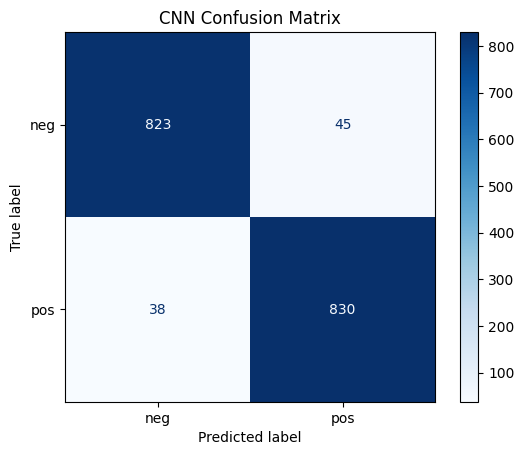

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict probabilities → convert to 0/1 predictions
y_pred_cnn_prob = model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["neg", "pos"])

plt.figure(figsize=(5,5))
disp.plot(values_format="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.show()


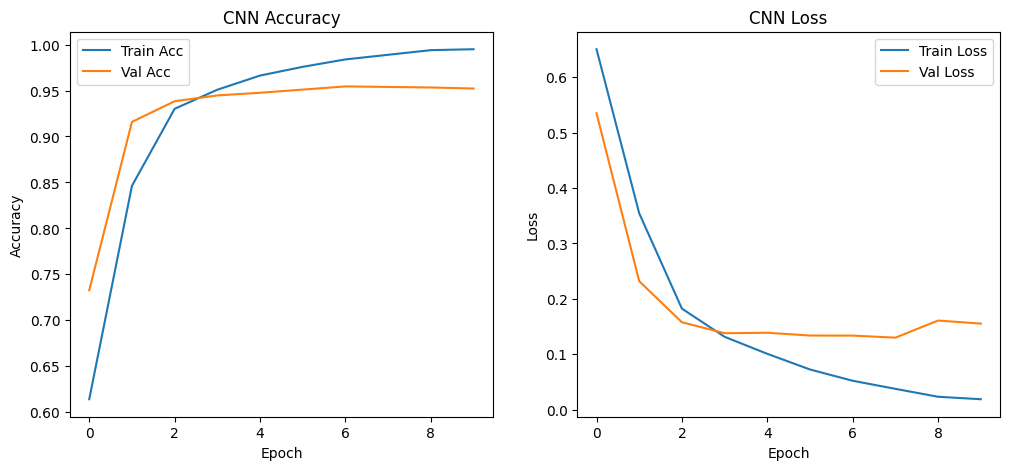

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy curve
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [ ]:
#This saves the model!
MODEL_SAVE_PATH = f"{BASE_PATH}/cnn_start_predictor.h5"
model.save(MODEL_SAVE_PATH)

print("Model saved to:", MODEL_SAVE_PATH)


Model saved to: /content/drive/MyDrive/CSCI4481 Project/Bacteria/cnn_start_predictor.h5


In [ ]:
#This loads the model
from tensorflow.keras.models import load_model

MODEL_SAVE_PATH = f"{BASE_PATH}/cnn_start_predictor.h5"
loaded_model = load_model(MODEL_SAVE_PATH)

print("Model loaded successfully!")



Model loaded successfully!


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_cnn = (model.predict(X_test_cnn) > 0.5).astype(int)

print("CNN Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("CNN Precision:", precision_score(y_test, y_pred_cnn))
print("CNN Recall:", recall_score(y_test, y_pred_cnn))
print("CNN F1 Score:", f1_score(y_test, y_pred_cnn))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred_cnn))


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CNN Accuracy: 0.9521889400921659
CNN Precision: 0.9485714285714286
CNN Recall: 0.956221198156682
CNN F1 Score: 0.9523809523809523

Detailed Report:

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       868
           1       0.95      0.96      0.95       868

    accuracy                           0.95      1736
   macro avg       0.95      0.95      0.95      1736
weighted avg       0.95      0.95      0.95      1736



In [ ]:
for i in range(5):
    print("Sequence", i)
    print("True Label:", y_test[i])
    print("Predicted:", int(y_pred_cnn[i][0]))
    print("Probability:", float(y_pred_cnn_prob[i][0]))
    print("-" * 40)


NameError: name 'y_pred' is not defined